# Figure S6

In [ ]:
%%bash
### download uhgv hq genomes
# wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_hq_plus.fna.gz
# wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv

In [ ]:
%%bash
### dereplicate UHGV HQ genomes using seqhasher
# /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhgdb/bin/seq-hasher \
#     uhgv_hq_plus.fna.gz \
#     --multi-kmer-hashing \
#     --circular-kmers \
#     > uhgv.seq-hasher.tsv

# csvtk uniq \
#     uhgv.seq-hasher.tsv \
#     --no-header-row \
#     --fields 2 \
#     --num-cpus 32 \
#     --tabs \
#     --out-file uhgv.csvtk_uniq.tsv.gz

# csvtk cut \
#     --tabs \
#     uhgv.csvtk_uniq.tsv.gz \
#     --fields 1 \
#     --out-file pattern.tsv

# seqkit \
#     grep \
#     --threads 32 \
#     --pattern-file pattern.tsv \
#     uhgv_hq_plus.fna.gz \
#     -o uhgv.seqkit_derep.fna.gz

In [ ]:
%%bash
### run vclust on dereplicated genomes to create all-v-all gANI matrix
# micromamba activate vclust

# vclust \
#     prefilter \
#     --in uhgv.seqkit_derep.fna.gz \
#     --out uhgv_hq_plus.vclust_prefilter.txt \
#     --threads 60 \
#     --min-ident 0.95

# vclust \
#     align \
#     --in uhgv.seqkit_derep.fna.gz \
#     --out uhgv_hq_plus.vclust_ani.tsv \
#     --filter uhgv_hq_plus.vclust_prefilter.txt \
#     --threads 60 \
#     --out-ani 0.95 \
#     --out-qcov 0.85

# csvtk cut \
#     uhgv_hq_plus.vclust_ani.tsv \
#     --num-cpus 32 \
#     --tabs \
#     --out-tabs \
#     --delete-header \
#     --fields query,reference,gani \
#     --out-file uhgv_hq_plus.vclust_gani_all2all.tsv

In [ ]:
%%bash
### subset UHGV HQ genomes and run mcl on subsets
# seqkit fx2tab \
#     uhgv.seqkit_derep.fna.gz \
#     --only-id --name --no-qual \
#     --out-file uhgv.seqkit_derep.ids.tsv

# for rep in {1..5}; do
#     for subset in "1000" "5000" "10000" "20000" "50000" "100000"; do
#         mkdir -p subset_${subset}/

#         shuf --random-source=<(yes $rep) -n $subset \
#             uhgv.seqkit_derep.ids.tsv \
#             > subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_ids.tsv

#         csvtk join --tabs \
#             -f "1;1" \
#             uhgv_hq_plus.vclust_gani_all2all.tsv \
#             subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_ids.tsv | \
#         csvtk join --tabs \
#             -f "2;1" \
#             - subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_ids.tsv \
#             --out-file subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_gani.tsv

#         micromamba run -n mcl \
#             mcl \
#                 subset_${subset}/uhgv_hq_plus.subset${subset}_rep${rep}_gani.tsv \
#                 --abc \
#                 -sort revsize \
#                 -te 32 \
#                 -o uhgv_hq_plus.subset${subset}_rep${rep}.mcl
#     done
# done

[mcl] new tab created
[mcl] pid 99926
 ite   chaos  time hom(avg,lo,hi) m-ie m-ex i-ex fmv
  1     3.28  0.00 1.01/0.54/2.71 1.08 1.08 1.08  15
  2     3.41  0.00 0.97/0.64/1.32 1.01 1.01 1.08  16
  3     2.45  0.00 0.94/0.49/2.65 1.00 0.99 1.08  16
  4     1.69  0.00 0.93/0.45/1.30 1.00 0.99 1.06  16
  5     1.81  0.00 0.92/0.43/1.08 1.00 0.96 1.02  16
  6     2.00  0.00 0.90/0.42/1.22 1.00 0.94 0.95  16
  7     1.39  0.00 0.87/0.52/1.00 1.00 0.95 0.90  14
  8     2.59  0.00 0.84/0.40/1.00 1.00 0.94 0.85  11
  9     7.34  0.00 0.83/0.16/1.00 1.00 0.87 0.74  10
 10    14.22  0.00 0.87/0.29/1.00 1.00 0.82 0.61   8
 11     3.94  0.00 0.92/0.44/1.00 1.00 0.58 0.36   7
 12     0.92  0.00 0.96/0.63/1.00 1.00 0.62 0.22   7
 13     0.58  0.00 0.98/0.72/1.00 1.00 0.79 0.17   0
 14     0.40  0.00 0.98/0.73/1.00 1.00 0.89 0.15   0
 15     0.57  0.00 0.99/0.69/1.00 1.00 0.94 0.15   0
 16     0.65  0.00 0.99/0.65/1.00 1.00 0.98 0.14   0
 17     0.47  0.00 0.99/0.66/1.00 1.00 0.98 0.14   0
 18     

In [ ]:
%%bash
### run mcl on full dereplicated set
# mkdir -p subset_full/

# cat \
#     uhgv.seqkit_derep.ids.tsv \
#     > subset_full/uhgv_hq_plus.subsetfull_ids.tsv

# micromamba run -n mcl \
#     mcl \
#         uhgv_hq_plus.vclust_gani_all2all.tsv \
#         --abc \
#         -sort revsize \
#         -te 32 \
#         -o uhgv_hq_plus.subsetfull.mcl

In [1]:
### function to load mcl clusters
def load_mcl_clusters(mcl, seq_id):
    # assign sequences to mcl clusters
    clusters = {}

    cluster_id = 0
    with open(mcl, 'r') as mcl_file:
        for line in mcl_file:
            cluster_id += 1
            for node in line.strip().split():
                clusters[node] = cluster_id

    # assign unclustered sequences to their own cluster
    with open(seq_id, 'r') as seqid_file:
        for line in seqid_file:
            sequence = line.strip()
            if sequence not in clusters:
                cluster_id += 1
                clusters[sequence] = cluster_id

    # convert to a DataFrame
    clusters_df = pl.DataFrame({
        'seq_id': list(clusters.keys()),
        'cluster_id': list(clusters.values())
    })

    return clusters_df

In [2]:
### calculate homogeneity and completeness scores for UHGV cluster subsets
from sklearn.metrics.cluster import homogeneity_score
from sklearn.metrics.cluster import completeness_score
from sklearn.metrics import v_measure_score
import polars as pl

results = []

subsets = ['1000', '5000', '10000', '20000', '50000', '100000']

for rep in range(1, 6):
    for i in range(len(subsets)):
        clusters = load_mcl_clusters(f'uhgv_hq_plus.subset{subsets[i]}_rep{rep}.mcl', f'subset_{subsets[i]}/uhgv_hq_plus.subset{subsets[i]}_rep{rep}_ids.tsv').sort(pl.col('seq_id'), descending=False)
        multi_seq_clusters = set(clusters.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
        clusters_filt = clusters.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

        clusters_full = load_mcl_clusters('uhgv_hq_plus.subsetfull.mcl', 'subset_full/uhgv_hq_plus.subsetfull_ids.tsv').sort(pl.col('seq_id'), descending=False)

        # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
        h_score = homogeneity_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

        # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
        c_score = completeness_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

        # calculate v-measure score
        v_score = v_measure_score(clusters['cluster_id'], clusters_full.filter(pl.col('seq_id').is_in(clusters['seq_id']))['cluster_id'])

        results.append({
            "subset": subsets[i],
            "replicate": rep,
            "num_sequences": clusters['seq_id'].n_unique(),
            "All clusters": clusters['cluster_id'].n_unique(),
            "num_seqs_in_multi_seq_clusters": clusters_filt['seq_id'].n_unique(),
            "Non-singleton clusters": clusters_filt['cluster_id'].n_unique(),
            "homogeneity": h_score,
            "completeness": c_score,
            "v_measure": v_score
        })

    # Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters (merging lowers score)
    # Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters (splitting lowers score)
    # v-measure: harmonic mean of homogeneity and completeness

    multi_seq_clusters_full = set(clusters_full.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
    clusters_full_filt = clusters_full.filter(pl.col('cluster_id').is_in(multi_seq_clusters_full))

    results.append({
        "subset": "186221",
        "replicate": 1,
        "num_sequences": clusters_full['seq_id'].n_unique(),
        "All clusters": clusters_full['cluster_id'].n_unique(),
        "num_seqs_in_multi_seq_clusters": clusters_full_filt['seq_id'].n_unique(),
        "Non-singleton clusters": clusters_full_filt['cluster_id'].n_unique(),
        "homogeneity": None,
        "completeness": None,
        "v-measure": None
    })

Text(0, 0.5, 'Score')

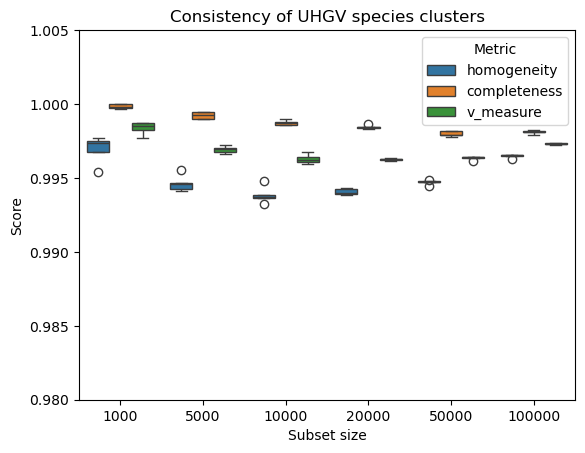

In [4]:
### plot homogeneity, completeness, and v-measure scores by subset
import seaborn as sns
import matplotlib.pyplot as plt

subset_results = (
    pl.from_dicts(results)
        .unpivot(index=["subset", "replicate", "num_sequences", "All clusters", "num_seqs_in_multi_seq_clusters", "Non-singleton clusters"], on=["homogeneity", "completeness", "v_measure"], variable_name="Metric", value_name="score")
        .filter(pl.col("subset") != "186221")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
ax = sns.boxplot(x="subset", y="score", data=subset_results, hue="Metric")
plt.ylim(0.98, 1.005)
plt.title("Consistency of UHGV species clusters")
plt.xlabel("Subset size")
plt.ylabel("Score")

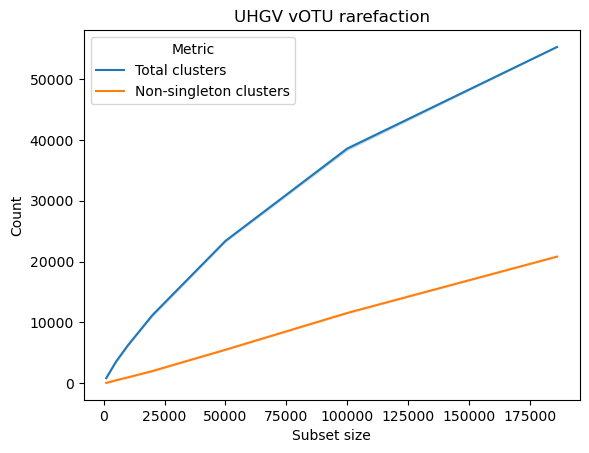

In [ ]:
### create rarefaction plot of cluster counts by subset
subset_cluster_counts = (
    pl.from_dicts(results)
        .with_columns([pl.col("subset").cast(pl.Int32)])
        .unpivot(index=["subset", "replicate"], on=["Total clusters", "Non-singleton clusters"], variable_name="metric", value_name="value")
)

# create a boxplot of v-measure, homogeneity, and completeness scores by subset
sns.lineplot(x="subset", y="value", hue='metric', data=subset_cluster_counts)
plt.title("UHGV vOTU rarefaction")
plt.xlabel("Subset size")
plt.ylabel("Count")
plt.legend(title='Metric', loc='upper left')

In [ ]:
### compare original UHGV clusters to UHVDB clustering of the same genomes
uhgv_v_uhvdb_results = []

clusters_full = load_mcl_clusters('uhgv_hq_plus.subsetfull.mcl', 'subset_full/uhgv_hq_plus.subsetfull_ids.tsv').sort(pl.col('seq_id'), descending=False)

uhgv_clusters = (
    pl.read_csv('uhgv_metadata.tsv', separator='\t',
        columns=['uhgv_genome', 'uhgv_votu']
    )
    .filter(
        (pl.col('uhgv_genome').is_in(clusters_full['seq_id']))
    )
    .with_columns([
        pl.col('uhgv_votu').str.split('-').list[1].alias('uhgv_votu')
    ])
    .sort(pl.col('uhgv_genome'), descending=False)
    [['uhgv_genome', 'uhgv_votu']]
)

multi_uhgv_clusters = set(uhgv_clusters.group_by('uhgv_votu').len().filter(pl.col('len') > 1)['uhgv_votu'])
uhgv_clusters_filt = uhgv_clusters.filter(pl.col('uhgv_votu').is_in(multi_uhgv_clusters))

multi_seq_clusters = set(clusters_full.group_by('cluster_id').len().filter(pl.col('len') > 1)['cluster_id'])
clusters_full_filt = clusters_full.filter(pl.col('cluster_id').is_in(multi_seq_clusters))

# Homogeneity: measure of how often genomes in new clusters were also clustered together in prior clusters
h_score = homogeneity_score(uhgv_clusters['uhgv_votu'], clusters_full['cluster_id'])

# Completeness: measure of how often UHGV genomes that were clustered together in prior clusters are also clustered together in new clusters
c_score = completeness_score(uhgv_clusters['uhgv_votu'], clusters_full['cluster_id'])

# calculate v-measure score
v_score = v_measure_score(uhgv_clusters['uhgv_votu'], clusters_full['cluster_id'])

uhgv_v_uhvdb_results.append({
    "num_uhgv_clusters": uhgv_clusters['uhgv_votu'].n_unique(),
    "num_multi_seq_uhgv_clusters": uhgv_clusters_filt['uhgv_votu'].n_unique(),
    "num_seqs_in_multi_seq_uhgv_clusters": uhgv_clusters_filt.shape[0],
    "num_uhvdb_clusters": clusters_full['cluster_id'].n_unique(),
    "num_multi_seq_uhvdb_clusters": clusters_full_filt['cluster_id'].n_unique(),
    "num_seqs_in_multi_seq_uhvdb_clusters": clusters_full_filt.shape[0],
    "h_score": h_score,
    "c_score": c_score,
    "v_score": v_score
})

In [ ]:
### display results
pl.from_dicts(uhgv_v_uhvdb_results)

num_uhgv_clusters,num_multi_seq_uhgv_clusters,num_seqs_in_multi_seq_uhgv_clusters,num_uhvdb_clusters,num_multi_seq_uhvdb_clusters,num_seqs_in_multi_seq_uhvdb_clusters,h_score,c_score,v_score
i64,i64,i64,i64,i64,i64,f64,f64,f64
58043,21597,149775,55252,20816,151785,0.987272,0.996316,0.991773


In [5]:
### new uhgv votu selection script
import polars as pl

def load_clusters(metadata):
    clusters = pl.read_csv(metadata, separator='\t', columns=['uhgv_genome', 'uhgv_votu'], ignore_errors=True)

    return clusters


def load_metadata(metadata, completeness, clusters):
    mine_report = (
        # load uhgv metadata
        pl.read_csv(metadata, separator='\t', columns=['uhgv_genome', 'genome_length', 'checkv_viral_markers', 'checkv_completeness_method'], ignore_errors=True)
            .join(
                pl.read_csv(completeness, separator='\t', columns=['contig_id', 'aai_expected_length', 'aai_confidence', 'aai_completeness'], ignore_errors=True),
                how='full', left_on='uhgv_genome', right_on='contig_id'
            )
            # retain only sequences that are in clusters
            .join(
                clusters, on='uhgv_genome', how='inner'
            )
    )

    return mine_report

def votu_rep_selection(metadata, completeness):
    # vClust Cluster Reps
    # 1. identify median length for each cluster
    # 2. Assign singletons as vOTU reps
    # 3. Assign longest DTRs (> median length) as vOTU reps
    # 4. Assign linear genome with highest number of viral genes (tiebreaker: closest to expected AAI length) as vOTU reps
    # 5. Output vOTU reps
    # 6. Output vClust vOTU cluster information

    # load cluster assignments
    clusters = load_clusters(metadata)

    # load sequence metadata
    mine_report = load_metadata(metadata, completeness, clusters)

    # 1. calculate median length amd size each cluster
    cluster_metrics = (
        mine_report.group_by('uhgv_votu').agg(
            [
                pl.col('genome_length').median().alias('median_length'),
                pl.col('checkv_viral_markers').max().alias('max_viral_genes'),
                pl.col('contig_id').len().alias('num_seqs')
            ]
        )
    )

    cluster_info = (
        mine_report
            .join(cluster_metrics, on='uhgv_votu', how='inner')
    )

    # 2. assign singletons as vOTU representatives
    singleton_clusters = set(
        cluster_metrics.filter(pl.col('num_seqs') == 1)['uhgv_votu']
    )

    cluster_reps = (
        mine_report
            .filter(pl.col('uhgv_votu').is_in(singleton_clusters))['contig_id', 'uhgv_votu']
    )

    # 3. assign longest DTRs as vOTU representatives (if > median length)
    dtr_cluster_reps = (
        cluster_info
            .filter(
                (
                    (pl.col('checkv_completeness_method').str.contains('DTR'))
                ) &
                (~pl.col('uhgv_votu').is_in(cluster_reps['uhgv_votu']))
            )
            .filter(pl.col('genome_length') >= pl.col('median_length'))
            .sort('genome_length', descending=True)
            .group_by('uhgv_votu', maintain_order=True)
            .first()['contig_id', 'uhgv_votu']
    )

    cluster_reps = pl.concat([cluster_reps, dtr_cluster_reps])

    # 4. Assign linear genome closest to expected AAI length with highest number of viral genes
    linear_cluster_reps = (
        cluster_info
            .filter(
                (~pl.col('uhgv_votu').is_in(cluster_reps['uhgv_votu'])) &
                (pl.col('checkv_viral_markers') == pl.col('max_viral_genes'))
            )
            .with_columns([
                pl.col('aai_expected_length').cast(pl.String).str.replace('NA', pl.col('median_length')).cast(pl.Float64).alias('aai_expected_length'),
            ])
            .with_columns([
                (abs(pl.col('aai_expected_length').cast(pl.Float64) - pl.col('genome_length').cast(pl.Float64))).alias('length_diff'),
            ])
            .sort(pl.col('length_diff'), descending=False)
            .group_by('uhgv_votu', maintain_order=True)
            .first()['contig_id', 'uhgv_votu']
    )

    cluster_reps = pl.concat([cluster_reps, linear_cluster_reps])

    # 5. Output vOTU representatives
    cluster_reps_ids = cluster_reps[['contig_id']]

    # 6. Output cluster information
    cluster_info = (
        cluster_info
            [['contig_id', 'uhgv_votu', 'num_seqs', 'genome_length', 'median_length', 'aai_expected_length', 'checkv_viral_markers', 'max_viral_genes', 'checkv_completeness_method']]
            .join(cluster_reps, on=['uhgv_votu'], how='full', suffix='_rep')
            .drop(['uhgv_votu_rep'])
            .rename({'contig_id_rep': 'votu_rep_new'})
    )

    return cluster_reps_ids, cluster_info

In [6]:
### evaluate rep selection with new script vs prior UHGV selection
# !wget https://portal.nersc.gov/cfs/m342/UHGV/mysql/tsv/checkv_completeness.tsv
# !wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv

cluster_reps, cluster_info = votu_rep_selection(
    'uhgv_metadata.tsv',
    'checkv_completeness.tsv'
)

In [7]:
### compare new votu reps to prior votu reps
uhgv_meta_reps = (
    pl.read_csv('uhgv_metadata.tsv', separator='\t', columns=['uhgv_genome', 'uhgv_votu', 'checkv_viral_markers', 'votu_representative', 'genome_length'], ignore_errors=True)
        .filter(pl.col('votu_representative') == 'Yes')
        .join(cluster_info.filter(pl.col('contig_id') == (pl.col('votu_rep_new')))[['contig_id', 'uhgv_votu', 'votu_rep_new', 'genome_length', 'checkv_viral_markers', 'max_viral_genes', 'aai_expected_length', 'checkv_completeness_method']].unique(pl.col('uhgv_votu')), on='uhgv_votu', suffix='_new', how='inner')
)
uhgv_meta_reps.sort(pl.col('uhgv_votu'), descending=False)
print("Total number of vOTUs in UHGV:", uhgv_meta_reps['uhgv_votu'].n_unique())
print("Number of vOTUs with matching representatives:", uhgv_meta_reps.filter(pl.col('uhgv_genome') == pl.col('votu_rep_new')).shape[0])
print("Number of non-matches with same length & viral gene count:", 
    uhgv_meta_reps
        .filter(
            (pl.col('uhgv_genome') != pl.col('votu_rep_new')) &
            (pl.col('genome_length') == pl.col('genome_length_new')) &
            (pl.col('checkv_viral_markers') == pl.col('checkv_viral_markers_new'))
        )
        .shape[0]
)

Total number of vOTUs in UHGV: 168536
Number of vOTUs with matching representatives: 152541
Number of non-matches with same length & viral gene count: 7038
